# Active and demand weeks in processed DST data

This notebook compares the article-store coverage of the processed DST datasets in `data/processed`:

- `transactions_dst_over_days_fcm` / `transactions_dst_over_days`: daily active-open-day rows, grouped to week starts for this analysis.
- `transactions_dst_over_weeks_fcm` / `transactions_dst_over_weeks`: weekly active-week rows produced from the daily DST dataset.

When the FCM-suffixed processed datasets are available, this notebook uses them; otherwise it falls back to the base processed datasets.

Definitions used below:

- **Active week**: an article-store-week with at least one active open-day observation in the daily data, or one row in the weekly data.
- **Demand week**: an active week whose aggregated `ABVERKAUFTE_MENGE_KG` is greater than zero.
- **Zero week**: an active week with no positive demand.

The weekly dataset should match the daily dataset after grouping daily rows to Monday week starts; the consistency check below verifies that assumption before interpreting the distributions.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
MIN_ACTIVE_WEEKS = 52
MIN_DEMAND_WEEKS = 32
SOURCE_LABELS = {
    "daily_dst_grouped_to_weeks": "Daily DST grouped to weeks",
    "weekly_dst": "Weekly DST",
}

processed_candidates = [
    Path("../../data/processed"),
    Path("../data/processed"),
    Path("data/processed"),
]
DATA_ROOT = next((path for path in processed_candidates if path.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError("Could not find data/processed from the current working directory.")

def has_parquet_files(path):
    return bool(sorted(path.glob("*.parquet")))


USE_FCM_DATASET = all(
    has_parquet_files(DATA_ROOT / name)
    for name in ["transactions_dst_over_days_fcm", "transactions_dst_over_weeks_fcm"]
)
DATASET_SUFFIX = "_fcm" if USE_FCM_DATASET else ""
DATASET_VARIANT = "FCM" if USE_FCM_DATASET else "base"

DATASETS = {
    "daily_dst_grouped_to_weeks": DATA_ROOT / f"transactions_dst_over_days{DATASET_SUFFIX}",
    "weekly_dst": DATA_ROOT / f"transactions_dst_over_weeks{DATASET_SUFFIX}",
}

for name, data_dir in DATASETS.items():
    files = sorted(data_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found for {name}: {data_dir}")
    print(f"{SOURCE_LABELS[name]} ({DATASET_VARIANT}): {len(files)} parquet files from {data_dir}")

Daily DST grouped to weeks (base): 2 parquet files from data/processed/transactions_dst_over_days
Weekly DST (base): 2 parquet files from data/processed/transactions_dst_over_weeks


## Compute active and demand weeks

For the daily DST data, rows are first aggregated to `date_trunc('week', DATE)`, which DuckDB returns as the Monday week-start date. This makes the metric directly comparable to the weekly DST data, where `DATE` already stores the week start.

The query keeps zero-demand weeks because they are part of the active DST series and are important for measuring intermittency.

In [2]:
def load_series_week_metrics(con, source_name, data_dir):
    parquet_glob = str(data_dir / "*.parquet")
    if source_name == "daily_dst_grouped_to_weeks":
        week_start_sql = "date_trunc('week', CAST(DATE AS DATE))::DATE"
    elif source_name == "weekly_dst":
        week_start_sql = "CAST(DATE AS DATE)"
    else:
        raise ValueError(f"Unknown source: {source_name}")

    query = f"""
    WITH period_data AS (
        SELECT
            ARTIKEL_ID,
            MARKT_ID,
            {week_start_sql} AS week_start,
            SUM(CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE)) AS weekly_demand
        FROM read_parquet(?)
        GROUP BY ARTIKEL_ID, MARKT_ID, week_start
    ), series AS (
        SELECT
            ARTIKEL_ID,
            MARKT_ID,
            COUNT(*) AS active_weeks,
            SUM(CASE WHEN weekly_demand > 0 THEN 1 ELSE 0 END) AS demand_weeks,
            SUM(weekly_demand) AS total_demand_kg,
            MIN(week_start) AS first_active_week,
            MAX(week_start) AS last_active_week
        FROM period_data
        GROUP BY ARTIKEL_ID, MARKT_ID
    )
    SELECT
        '{source_name}' AS source,
        *,
        active_weeks - demand_weeks AS zero_weeks,
        demand_weeks / NULLIF(active_weeks, 0) AS demand_week_share
    FROM series
    ORDER BY ARTIKEL_ID, MARKT_ID
    """
    return con.execute(query, [parquet_glob]).fetchdf()


con = duckdb.connect()
con.execute("PRAGMA threads=4")

series_metrics = pd.concat(
    [load_series_week_metrics(con, name, data_dir) for name, data_dir in DATASETS.items()],
    ignore_index=True,
)
series_metrics["source_label"] = series_metrics["source"].map(SOURCE_LABELS)
series_metrics.head()

,source,ARTIKEL_ID,MARKT_ID,active_weeks,demand_weeks,total_demand_kg,first_active_week,last_active_week,zero_weeks,demand_week_share,source_label
0,daily_dst_grouped_to_weeks,1376860,1100039,53,33.000,20.232,2025-06-30,2026-06-29,20.000,0.623,Daily DST grouped to weeks
1,daily_dst_grouped_to_weeks,1376860,1100044,58,41.000,26.431,2025-05-26,2026-06-29,17.000,0.707,Daily DST grouped to weeks
2,daily_dst_grouped_to_weeks,1376860,1100047,58,45.000,42.815,2025-05-26,2026-06-29,13.000,0.776,Daily DST grouped to weeks
3,daily_dst_grouped_to_weeks,1376860,1100051,58,48.000,43.758,2025-05-26,2026-06-29,10.000,0.828,Daily DST grouped to weeks
4,daily_dst_grouped_to_weeks,1376860,1300023,56,34.000,118.933,2025-06-09,2026-06-29,22.000,0.607,Daily DST grouped to weeks


## Daily-versus-weekly consistency

The weekly DST data is expected to be the daily DST data aggregated to week starts. The check below compares the article-store series and their active-week, demand-week, zero-week, and total-demand metrics across both sources.

In [3]:
daily_series = (
    series_metrics[series_metrics["source"] == "daily_dst_grouped_to_weeks"]
    .drop(columns=["source", "source_label"])
    .sort_values(GROUP_COLS)
    .reset_index(drop=True)
)
weekly_series = (
    series_metrics[series_metrics["source"] == "weekly_dst"]
    .drop(columns=["source", "source_label"])
    .sort_values(GROUP_COLS)
    .reset_index(drop=True)
)

consistency = daily_series.merge(
    weekly_series,
    on=GROUP_COLS,
    how="outer",
    suffixes=("_daily", "_weekly"),
    indicator=True,
)

checks = [
    {"check": "series only in daily grouped data", "value": int((consistency["_merge"] == "left_only").sum())},
    {"check": "series only in weekly data", "value": int((consistency["_merge"] == "right_only").sum())},
]
for metric in ["active_weeks", "demand_weeks", "zero_weeks"]:
    diff = consistency[f"{metric}_daily"] - consistency[f"{metric}_weekly"]
    checks.append({"check": f"{metric} mismatched series", "value": int(diff.fillna(1).ne(0).sum())})

demand_diff = consistency["total_demand_kg_daily"] - consistency["total_demand_kg_weekly"]
checks.append({
    "check": "max absolute total-demand difference kg",
    "value": float(demand_diff.abs().max()),
})

consistency_summary = pd.DataFrame(checks)
display(consistency_summary)

,check,value
0,series only in daily grouped data,0.000
1,series only in weekly data,0.000
2,active_weeks mismatched series,0.000
3,demand_weeks mismatched series,0.000
4,zero_weeks mismatched series,0.000
5,max absolute total-demand difference kg,0.000


## General statistics

The table summarizes the number of article-store series, total active and demand weeks, and typical series-level coverage. A high zero-week share means many active weeks have no positive sales, even after weekly aggregation.

In [4]:
source_summary = (
    series_metrics
    .groupby("source_label", sort=False)
    .agg(
        series=("ARTIKEL_ID", "size"),
        products=("ARTIKEL_ID", "nunique"),
        stores=("MARKT_ID", "nunique"),
        first_active_week=("first_active_week", "min"),
        last_active_week=("last_active_week", "max"),
        active_weeks=("active_weeks", "sum"),
        demand_weeks=("demand_weeks", "sum"),
        zero_weeks=("zero_weeks", "sum"),
        total_demand_kg=("total_demand_kg", "sum"),
        mean_active_weeks=("active_weeks", "mean"),
        median_active_weeks=("active_weeks", "median"),
        mean_demand_weeks=("demand_weeks", "mean"),
        median_demand_weeks=("demand_weeks", "median"),
        median_demand_week_share=("demand_week_share", "median"),
    )
)
source_summary["demand_week_share_%"] = 100 * source_summary["demand_weeks"] / source_summary["active_weeks"]
source_summary["zero_week_share_%"] = 100 * source_summary["zero_weeks"] / source_summary["active_weeks"]

summary_display = source_summary[[
    "series", "products", "stores", "first_active_week", "last_active_week",
    "active_weeks", "demand_weeks", "zero_weeks", "demand_week_share_%", "zero_week_share_%",
    "total_demand_kg", "mean_active_weeks", "median_active_weeks",
    "mean_demand_weeks", "median_demand_weeks", "median_demand_week_share",
]].copy()

round_cols = [
    "demand_week_share_%", "zero_week_share_%", "total_demand_kg", "mean_active_weeks",
    "mean_demand_weeks", "median_demand_week_share",
]
summary_display[round_cols] = summary_display[round_cols].round(3)
display(summary_display)

,series,products,stores,first_active_week,last_active_week,active_weeks,demand_weeks,zero_weeks,demand_week_share_%,zero_week_share_%,total_demand_kg,mean_active_weeks,median_active_weeks,mean_demand_weeks,median_demand_weeks,median_demand_week_share
source_label,,,,,,,,,,,,,,,,
Daily DST grouped to weeks,298,43,21,2025-04-14,2026-06-29,11254,5489.000,5765.000,48.774,51.226,8713.026,37.765,42.000,18.419,11.000,0.392
Weekly DST,298,43,21,2025-04-14,2026-06-29,11254,5489.000,5765.000,48.774,51.226,8713.026,37.765,42.000,18.419,11.000,0.392


## Distribution statistics

The next table describes the per-series distributions of active weeks, demand weeks, zero weeks, and the demand-week share. Percentiles are useful here because the distributions are skewed: many article-store series have very few demand weeks, while a smaller group sells in most active weeks.

In [5]:
def describe_distribution(df, metrics, percentiles=(0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99)):
    rows = []
    for source_label, group in df.groupby("source_label", sort=False):
        for metric in metrics:
            values = group[metric].dropna()
            row = {
                "source": source_label,
                "metric": metric,
                "count": int(values.count()),
                "mean": values.mean(),
                "std": values.std(),
                "min": values.min(),
                "max": values.max(),
            }
            for p in percentiles:
                row[f"p{int(p * 100):02d}"] = values.quantile(p)
            rows.append(row)
    return pd.DataFrame(rows)


distribution_stats = describe_distribution(
    series_metrics,
    ["active_weeks", "demand_weeks", "zero_weeks", "demand_week_share"],
)

distribution_display = distribution_stats.copy()
for col in distribution_display.columns.difference(["source", "metric", "count"]):
    distribution_display[col] = distribution_display[col].round(3)
display(distribution_display)

,source,metric,count,mean,std,min,max,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,Daily DST grouped to weeks,active_weeks,298,37.765,17.015,2.000,64.000,2.000,3.000,12.000,24.000,42.000,50.000,58.000,61.000,63.000
1,Daily DST grouped to weeks,demand_weeks,298,18.419,19.064,1.000,64.000,1.000,1.000,1.000,2.000,11.000,30.000,53.300,57.000,60.030
2,Daily DST grouped to weeks,zero_weeks,298,19.346,15.508,0.000,52.000,0.000,0.000,1.000,4.000,17.000,31.750,43.000,44.000,47.000
3,Daily DST grouped to weeks,demand_week_share,298,0.453,0.337,0.021,1.000,0.022,0.031,0.046,0.112,0.392,0.750,0.958,1.000,1.000
4,Weekly DST,active_weeks,298,37.765,17.015,2.000,64.000,2.000,3.000,12.000,24.000,42.000,50.000,58.000,61.000,63.000
5,Weekly DST,demand_weeks,298,18.419,19.064,1.000,64.000,1.000,1.000,1.000,2.000,11.000,30.000,53.300,57.000,60.030
6,Weekly DST,zero_weeks,298,19.346,15.508,0.000,52.000,0.000,0.000,1.000,4.000,17.000,31.750,43.000,44.000,47.000
7,Weekly DST,demand_week_share,298,0.453,0.337,0.021,1.000,0.022,0.031,0.046,0.112,0.392,0.750,0.958,1.000,1.000


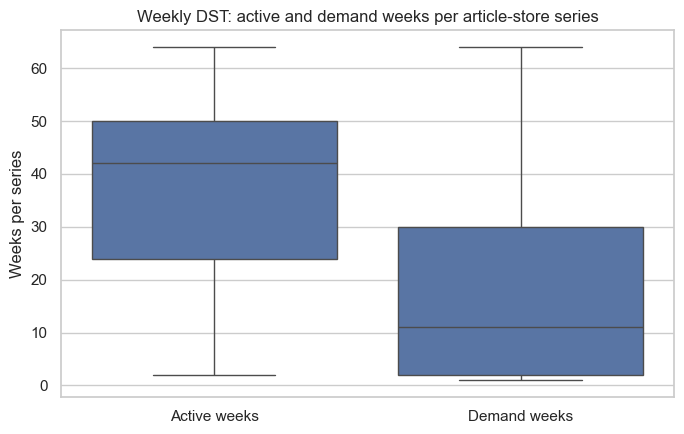

In [6]:
weekly_box_data = (
    series_metrics[series_metrics["source"] == "weekly_dst"]
    .melt(
        id_vars=GROUP_COLS,
        value_vars=["active_weeks", "demand_weeks"],
        var_name="metric",
        value_name="weeks",
    )
)
weekly_box_data["metric"] = weekly_box_data["metric"].map({
    "active_weeks": "Active weeks",
    "demand_weeks": "Demand weeks",
})

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=weekly_box_data,
    x="metric",
    y="weeks",
    order=["Active weeks", "Demand weeks"],
    ax=ax,
)
ax.set_title("Weekly DST: active and demand weeks per article-store series")
ax.set_xlabel("")
ax.set_ylabel("Weeks per series")

plt.tight_layout()
plt.show()

## Binned week-count distributions

The binned view makes the sparsity easier to scan. Active weeks describe how long a series is observed; demand weeks describe how often the series actually sells within that active observation window.

In [7]:
week_bins = [0, 1, 4, 8, 13, 20, 26, 39, 52, 64, 78, 104, np.inf]
week_labels = ["1", "2-4", "5-8", "9-13", "14-20", "21-26", "27-39", "40-52", "53-64", "65-78", "79-104", ">104"]

binned_rows = []
for source_label, group in series_metrics.groupby("source_label", sort=False):
    for metric in ["active_weeks", "demand_weeks"]:
        binned = pd.cut(group[metric], bins=week_bins, labels=week_labels, include_lowest=True, right=True)
        counts = binned.value_counts(sort=False)
        for label in week_labels:
            count = int(counts.get(label, 0))
            binned_rows.append({
                "source": source_label,
                "metric": metric,
                "week_bin": label,
                "series": count,
                "series_share_%": 100 * count / len(group),
            })

binned_distribution = pd.DataFrame(binned_rows)
binned_distribution["series_share_%"] = binned_distribution["series_share_%"].round(1)
display(binned_distribution)

,source,metric,week_bin,series,series_share_%
0,Daily DST grouped to weeks,active_weeks,1,0,0.000
1,Daily DST grouped to weeks,active_weeks,2-4,22,7.400
2,Daily DST grouped to weeks,active_weeks,5-8,3,1.000
3,Daily DST grouped to weeks,active_weeks,9-13,13,4.400
4,Daily DST grouped to weeks,active_weeks,14-20,8,2.700
5,Daily DST grouped to weeks,active_weeks,21-26,40,13.400
6,Daily DST grouped to weeks,active_weeks,27-39,40,13.400
7,Daily DST grouped to weeks,active_weeks,40-52,106,35.600
8,Daily DST grouped to weeks,active_weeks,53-64,66,22.100
9,Daily DST grouped to weeks,active_weeks,65-78,0,0.000


## Interpretation

The key interpretation comes from comparing active weeks with demand weeks. Active-week coverage is moderate for most article-store series, but demand-week coverage is much lower: many active series have only a small number of weeks with positive sales. The weekly DST data is therefore consistent with the daily DST source, but it still contains substantial intermittent demand at the article-store level.

In [8]:
weekly_totals = source_summary.loc["Weekly DST"]
print(f"Article-store series: {int(weekly_totals['series']):,}")
print(f"Products: {int(weekly_totals['products']):,}; stores: {int(weekly_totals['stores']):,}")
print(f"Active weeks: {int(weekly_totals['active_weeks']):,}")
print(f"Demand weeks: {int(weekly_totals['demand_weeks']):,}")
print(f"Zero-week share: {weekly_totals['zero_week_share_%']:.1f}%")
print(f"Median active weeks per series: {weekly_totals['median_active_weeks']:.0f}")
print(f"Median demand weeks per series: {weekly_totals['median_demand_weeks']:.0f}")
print(f"Median demand-week share per series: {weekly_totals['median_demand_week_share']:.1%}")

Article-store series: 298
Products: 43; stores: 21
Active weeks: 11,254
Demand weeks: 5,489
Zero-week share: 51.2%
Median active weeks per series: 42
Median demand weeks per series: 11
Median demand-week share per series: 39.2%


In [9]:
weekly_series_query = f"""
WITH weekly_periods AS (
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        CAST(DATE AS DATE) AS week_start,
        SUM(CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE)) AS weekly_demand,
        ARG_MIN(ARTIKEL_BEZ, CAST(DATE AS DATE)) AS ARTIKEL_BEZ
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID, week_start
), series AS (
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        ARG_MIN(ARTIKEL_BEZ, week_start) AS ARTIKEL_BEZ,
        COUNT(*) AS active_weeks,
        SUM(CASE WHEN weekly_demand > 0 THEN 1 ELSE 0 END) AS demand_weeks,
        SUM(weekly_demand) AS total_demand_kg,
        MIN(week_start) AS first_active_week,
        MAX(week_start) AS last_active_week
    FROM weekly_periods
    GROUP BY ARTIKEL_ID, MARKT_ID
)
SELECT
    ARTIKEL_ID,
    MARKT_ID,
    ARTIKEL_BEZ,
    active_weeks,
    demand_weeks,
    total_demand_kg,
    first_active_week,
    last_active_week
FROM series
ORDER BY demand_weeks DESC, active_weeks DESC, ARTIKEL_ID, MARKT_ID
"""

weekly_requirement_series = con.execute(
    weekly_series_query,
    [str(DATASETS["weekly_dst"] / "*.parquet")],
).fetchdf()

meets_weekly_requirements = (
    (weekly_requirement_series["active_weeks"] >= MIN_ACTIVE_WEEKS)
    & (weekly_requirement_series["demand_weeks"] >= MIN_DEMAND_WEEKS)
)
eligible_weekly_series = weekly_requirement_series[meets_weekly_requirements].copy()
ineligible_weekly_series = weekly_requirement_series[~meets_weekly_requirements].copy()

print(f"Total weekly DST series: {len(weekly_requirement_series):,}")
print(
    f"Weekly DST series with active_weeks >= {MIN_ACTIVE_WEEKS} "
    f"and demand_weeks >= {MIN_DEMAND_WEEKS}: {len(eligible_weekly_series):,}"
)
print(
    f"Weekly DST series not meeting these requirements: "
    f"{len(ineligible_weekly_series):,}"
)
display(eligible_weekly_series)

Total weekly DST series: 298
Weekly DST series with active_weeks >= 52 and demand_weeks >= 32: 52
Weekly DST series not meeting these requirements: 246


,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,active_weeks,demand_weeks,total_demand_kg,first_active_week,last_active_week
0,1382768,1100076,Fleischkäse ofengebacken,64,64.000,96.979,2025-04-14,2026-06-29
1,1382768,1100055,Fleischkäse ofengebacken,64,61.000,96.065,2025-04-14,2026-06-29
2,1382766,1100055,Fleischwurst mit Knoblauch,61,61.000,65.278,2025-05-05,2026-06-29
3,1382768,1300004,Fleischkäse ofengebacken,63,60.000,128.578,2025-04-21,2026-06-29
4,1382767,1100025,Fleischwurst ohne Knoblauch,61,60.000,141.240,2025-05-05,2026-06-29
5,1382766,1300023,Fleischwurst mit Knoblauch,60,60.000,234.067,2025-05-12,2026-06-29
6,1382767,1300008,Fleischwurst ohne Knoblauch,60,60.000,203.951,2025-05-12,2026-06-29
7,1382767,1300023,Fleischwurst ohne Knoblauch,60,60.000,183.521,2025-05-12,2026-06-29
8,1382766,1100051,Fleischwurst mit Knoblauch,61,59.000,52.566,2025-05-05,2026-06-29
9,1382767,1100044,Fleischwurst ohne Knoblauch,61,59.000,54.891,2025-05-05,2026-06-29
